Here we are looking at the regulatory network of HDBSCAN Clusters 20+21 (pluripotency associated)

/scratch/ydoctor/job_6258854/ipykernel_2095354/1441111292.py:10: DtypeWarning: Columns (3,6,9,12,15,18,21,24,27,30,33,36,39,42,45,48,51,54,57,60,63,66,69,72,75,78,81,84,87,90,93,96,99,102,105,108,111,114,117,120,123,126,129,132,135,138,141,144,147,150,153,156,159,162,165,168,171,174,177,180,183,186,189,192,195,198,201,204,207,210,213,216,219,222,225,228,231,234,237,240,243,246,249,252,255,258,261,264,267,270,273,276,279,282,285,288,291,294,297,300,303,306,309,312,315,318,321,324,327,330,333,336,339,342,345,348,351,354,357,360,363,366,369,372,375,378,381,384,387,390,393,396,399,402,405,408,411,414,417,420,423,426,429,432,435,438,441,444,447,450,453,456,459,462,465,468,471,474,477,480,483,486,489,492,495,498,501,504,507,510,513,516,519,522,525,528,531,534,537,540,543,546,549,552,555,558,561,564,567,570,573,576,579,582,585,588,591,594,597,600,603,606,609,612,615,618,621,624,627,630,633,636,639,642,645,648,651,654,657,660,663,666,669,672,675,678,681,684,687,690,693,696,699,702,705,708,711,

Number of nodes: 31
Number of edges: 40


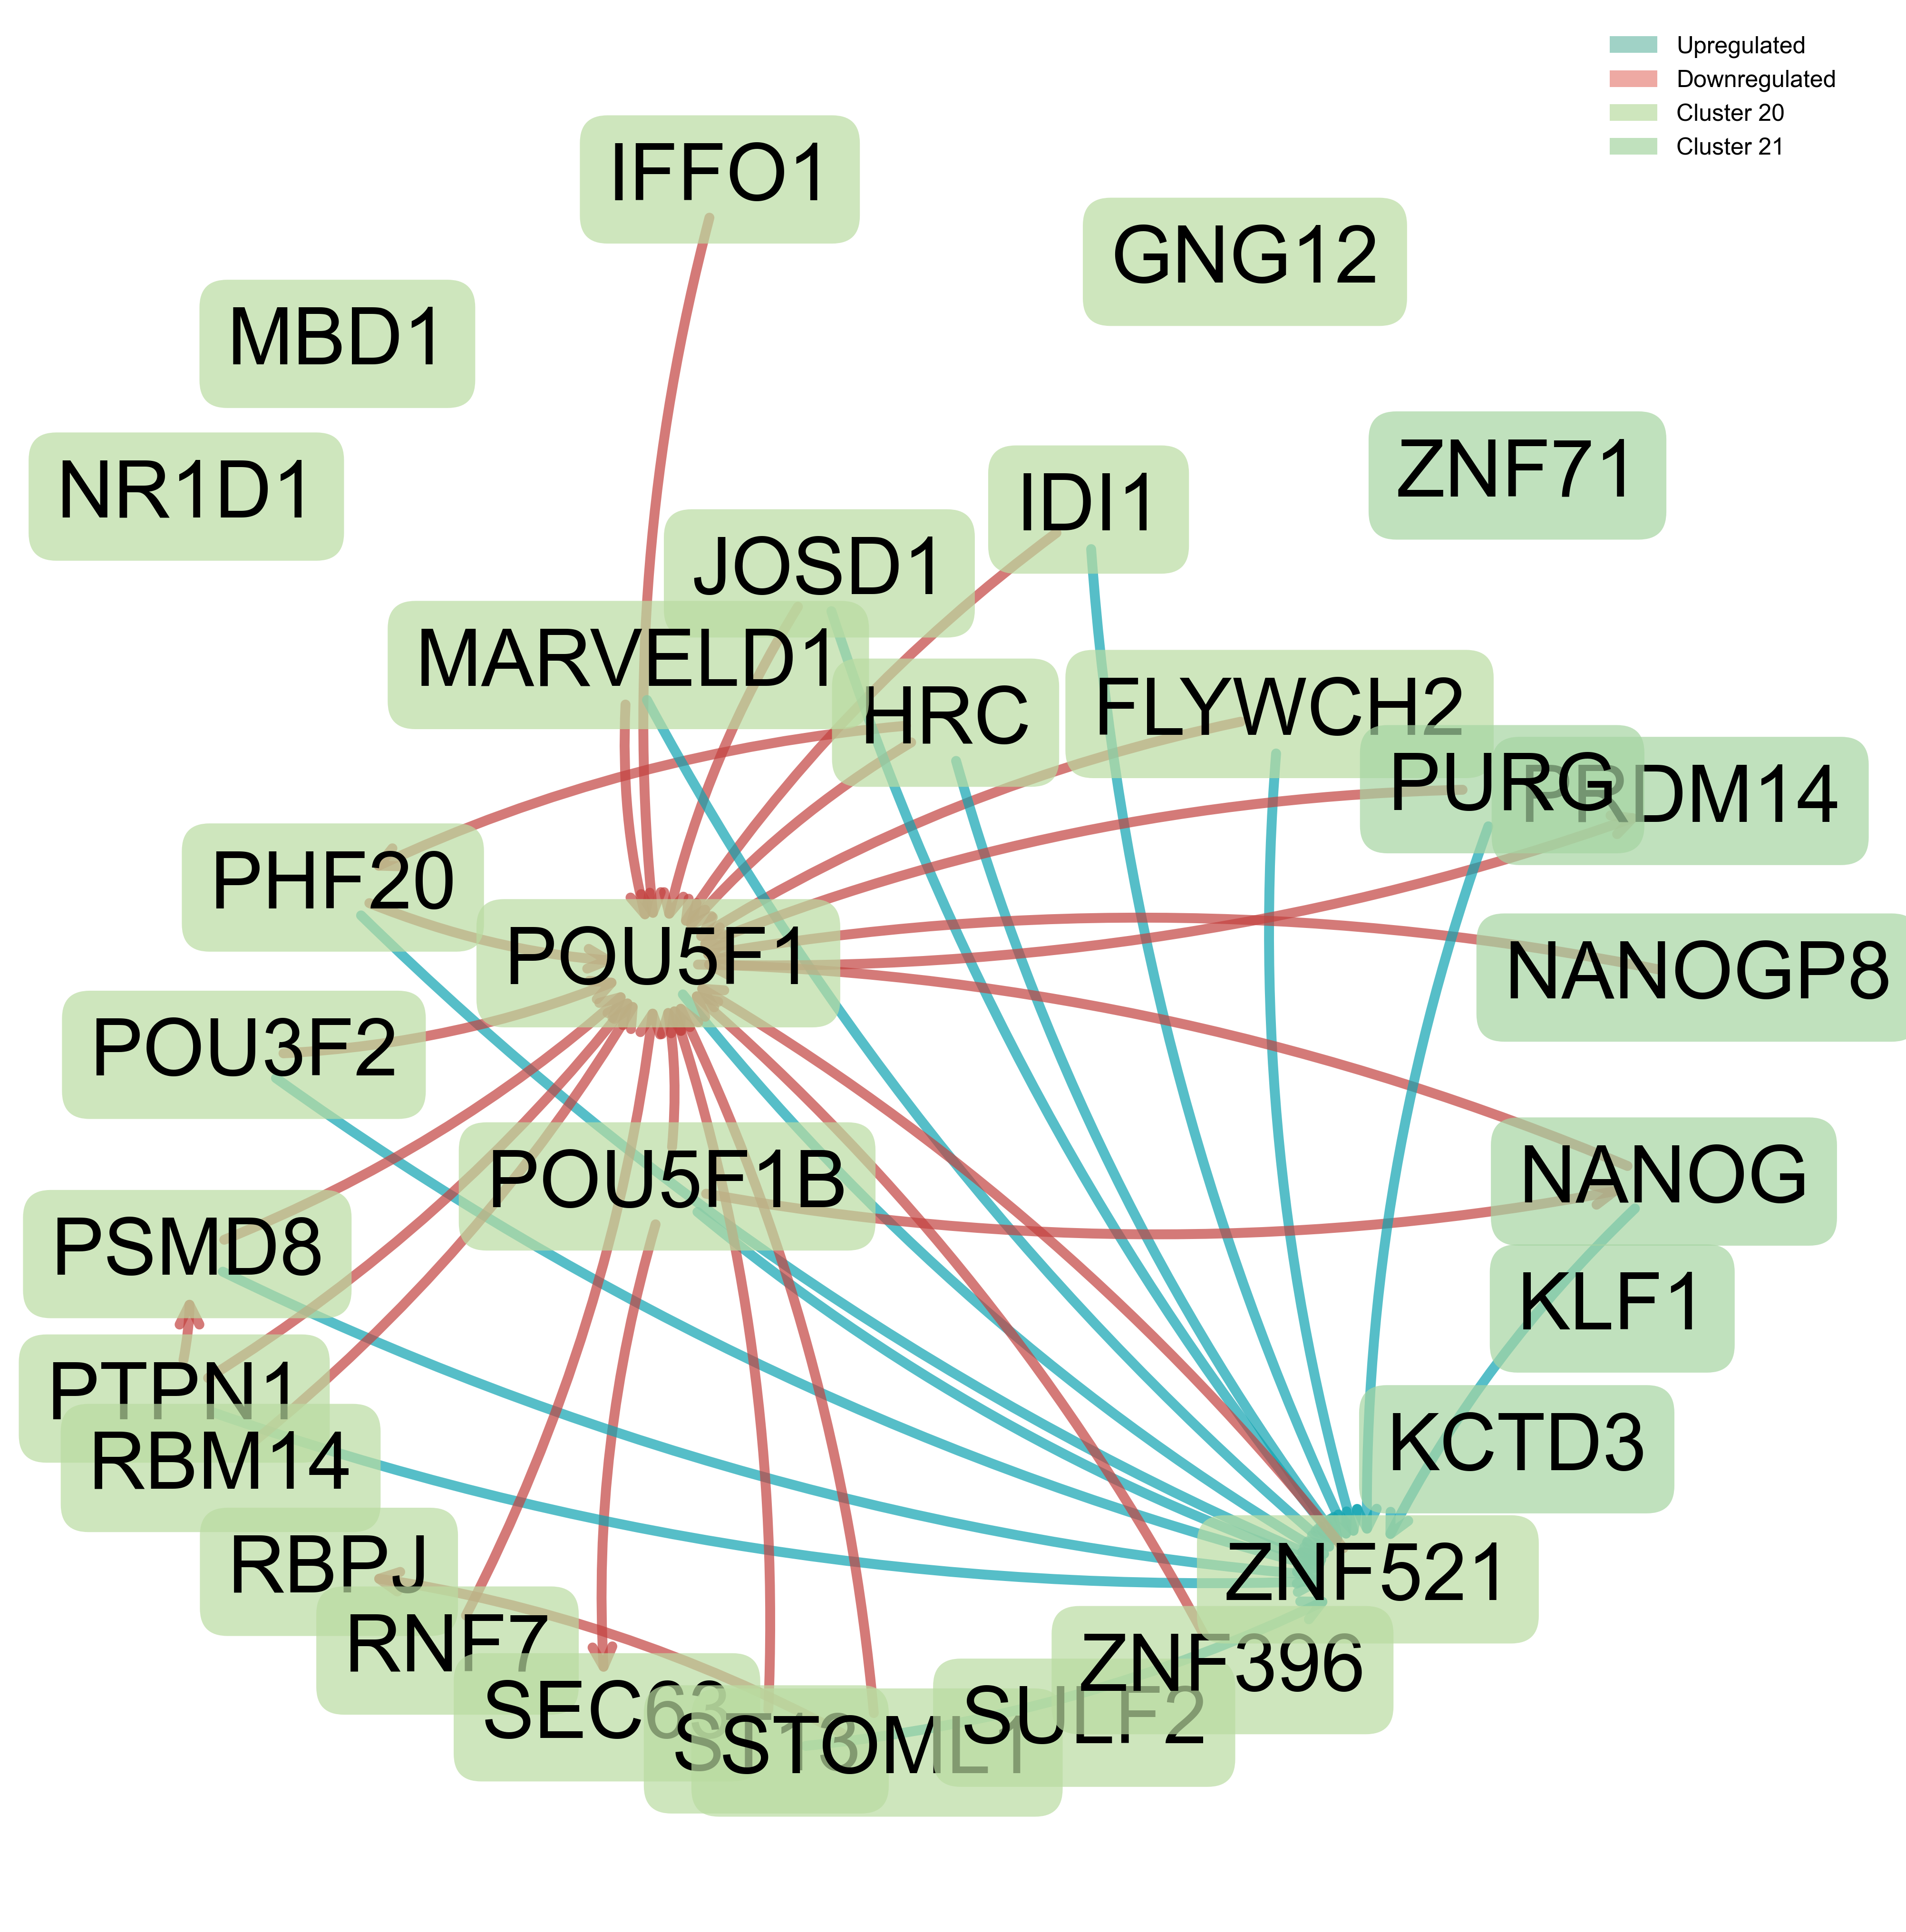

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Load data
clusters = pd.read_excel('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/output_files/KOLF_Pan_Genome_Filtered_Replogle_Pipeline_Modified_MDE_clusters.xlsx')
pluripotency_associated_genes = list(clusters[clusters['hdbscan cluster'].isin([20,21])].gene_target)
DEGs=pd.read_csv('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/output_files/KOLF_Pan_Genome_DEGs_per_Strong_Perturbation.csv')

# Map each gene to its cluster for coloring
gene_to_cluster = dict(zip(clusters['gene_target'], clusters['hdbscan cluster']))

gene_to_col = {}
for col in DEGs.columns:
    if col.endswith('_DEGs'):
        gene = col.split('_')[0]
        gene_to_col[gene] = col

upregulated_DEGs_per_gene = {}
downregulated_DEGs_per_gene = {}
for gene in pluripotency_associated_genes:
    l2fc_col = gene_to_col[gene].replace('_DEGs', '_L2FC')
    degs_data = DEGs[gene_to_col[gene]].dropna()
    l2fc_data = DEGs[l2fc_col].dropna()
    upregulated_mask = l2fc_data > 0
    downregulated_mask = l2fc_data <= 0
    upregulated_DEGs_per_gene[gene] = list(degs_data[upregulated_mask])
    downregulated_DEGs_per_gene[gene] = list(degs_data[downregulated_mask])

# Set font to Arial
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 22

# Create a directed graph
G = nx.DiGraph()
for gene in pluripotency_associated_genes:
    G.add_node(gene)
for source_gene, target_genes in upregulated_DEGs_per_gene.items():
    for target_gene in target_genes:
        if target_gene in G.nodes() and source_gene != target_gene:
            G.add_edge(source_gene, target_gene, **{"class":'+', 'color':'#0FA3B1'})
for source_gene, target_genes in downregulated_DEGs_per_gene.items():
    for target_gene in target_genes:
        if target_gene in G.nodes() and source_gene != target_gene:
            G.add_edge(source_gene, target_gene, **{"class":'-', 'color':'#C3423F'})

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

edge_colors = [G[u][v]['color'] for u, v in G.edges()]

# Assign node colors by cluster: 20 = badca1, 21 = a6d5a2
node_colors = []
for node in G.nodes():
    cluster = gene_to_cluster.get(node, None)
    if cluster == 20:
        node_colors.append('#badca1')
    elif cluster == 21:
        node_colors.append('#a6d5a2')
    else:
        node_colors.append('#b2e2f4')  # fallback color (shouldn't occur)

# --- Use a spring layout for better label separation ---
# Optionally, sort genes within each cluster alphabetically for reproducibility
cluster_20_genes = sorted([gene for gene in pluripotency_associated_genes if gene_to_cluster.get(gene) == 20])
cluster_21_genes = sorted([gene for gene in pluripotency_associated_genes if gene_to_cluster.get(gene) == 21])
ordered_genes = cluster_20_genes + cluster_21_genes

# Use spring layout, but initialize positions to help cluster separation
init_pos = {}
n_20 = len(cluster_20_genes)
n_21 = len(cluster_21_genes)
for i, gene in enumerate(cluster_20_genes):
    angle = np.pi * (i + 1) / (n_20 + 1) + np.pi/2
    init_pos[gene] = (np.cos(angle), np.sin(angle))
for i, gene in enumerate(cluster_21_genes):
    angle = np.pi * (i + 1) / (n_21 + 1) - np.pi/2
    init_pos[gene] = (np.cos(angle), np.sin(angle))
pos = nx.spring_layout(G, k=10, seed=42, pos=init_pos, iterations=200)

# Reorder node_colors to match ordered_genes
ordered_node_colors = []
for node in ordered_genes:
    cluster = gene_to_cluster.get(node, None)
    if cluster == 20:
        ordered_node_colors.append('#badca1')
    elif cluster == 21:
        ordered_node_colors.append('#a6d5a2')
    else:
        ordered_node_colors.append('#b2e2f4')

plt.figure(figsize=(14, 14), dpi=300)

# Draw edges
nx.draw_networkx_edges(
    G, pos,
    edge_color=edge_colors,
    arrows=True,
    arrowsize=25,
    arrowstyle='->',
    width=5,
    alpha=0.7,
    connectionstyle='arc3,rad=0.1',
    min_source_margin=20,
    min_target_margin=20
)

# Draw nodes as transparent (so only boxes will be visible)
nx.draw_networkx_nodes(
    G, pos,
    nodelist=ordered_genes,
    node_color='none',
    node_size=0,
    alpha=0
)

# Draw labels with bounding boxes (rectangular boxes as nodes)
for i, node in enumerate(ordered_genes):
    x, y = pos[node]
    cluster = gene_to_cluster.get(node, None)
    if cluster == 20:
        box_color = '#badca1'
    elif cluster == 21:
        box_color = '#a6d5a2'
    else:
        box_color = '#b2e2f4'
    plt.text(
        x, y, node,
        fontsize=40,
        fontfamily='Arial',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.35', facecolor=box_color, edgecolor='none', alpha=0.7)
    )

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#78c0af', alpha=0.7, label='Upregulated'),
    Patch(facecolor='#e7857c', alpha=0.7, label='Downregulated'),
    Patch(facecolor='#badca1', alpha=0.7, label='Cluster 20'),
    Patch(facecolor='#a6d5a2', alpha=0.7, label='Cluster 21')
]
plt.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=12,
    frameon=False,
    fancybox=False,
    shadow=False
)

plt.axis('off')
plt.tight_layout()
plt.savefig('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/output_files/Pluripotency_Associated_Regulatory_Network.svg')
plt.show()

# --- Save the graph in GraphML format ---
nx.write_graphml(
    G,
    '/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/output_files/Pluripotency_Associated_Regulatory_Network.graphml'
)

In [2]:
import pandas as pd

# Create a list to store edge data
edge_data = []

# For each edge in the graph, determine class (+ for upregulated, - for downregulated)
for source, target in G.edges():
    # Check if the edge has a 'Class' attribute (e.g., + or -)
    edge_class = G.edges[source, target].get('class', None)
    if edge_class is None:
        # If not present, default to '+' (or handle as needed)
        edge_class = '+'
    edge_data.append({'Node1': source, 'Node2': target, 'Class': edge_class})

# Create DataFrame
edges_df = pd.DataFrame(edge_data, columns=['Node1', 'Node2', 'Class'])

# Example: show the first few rows
print(edges_df.head())
edges_df.to_csv('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/output_files/Pluripotency_Associated_Regulatory_Network_edges.csv', index=False)

     Node1   Node2 Class
0  FLYWCH2  ZNF521     +
1  FLYWCH2  POU5F1     -
2      HRC  ZNF521     +
3      HRC  POU5F1     -
4      HRC   PHF20     -


Created full regulatory network with 1655 nodes and 7338 edges


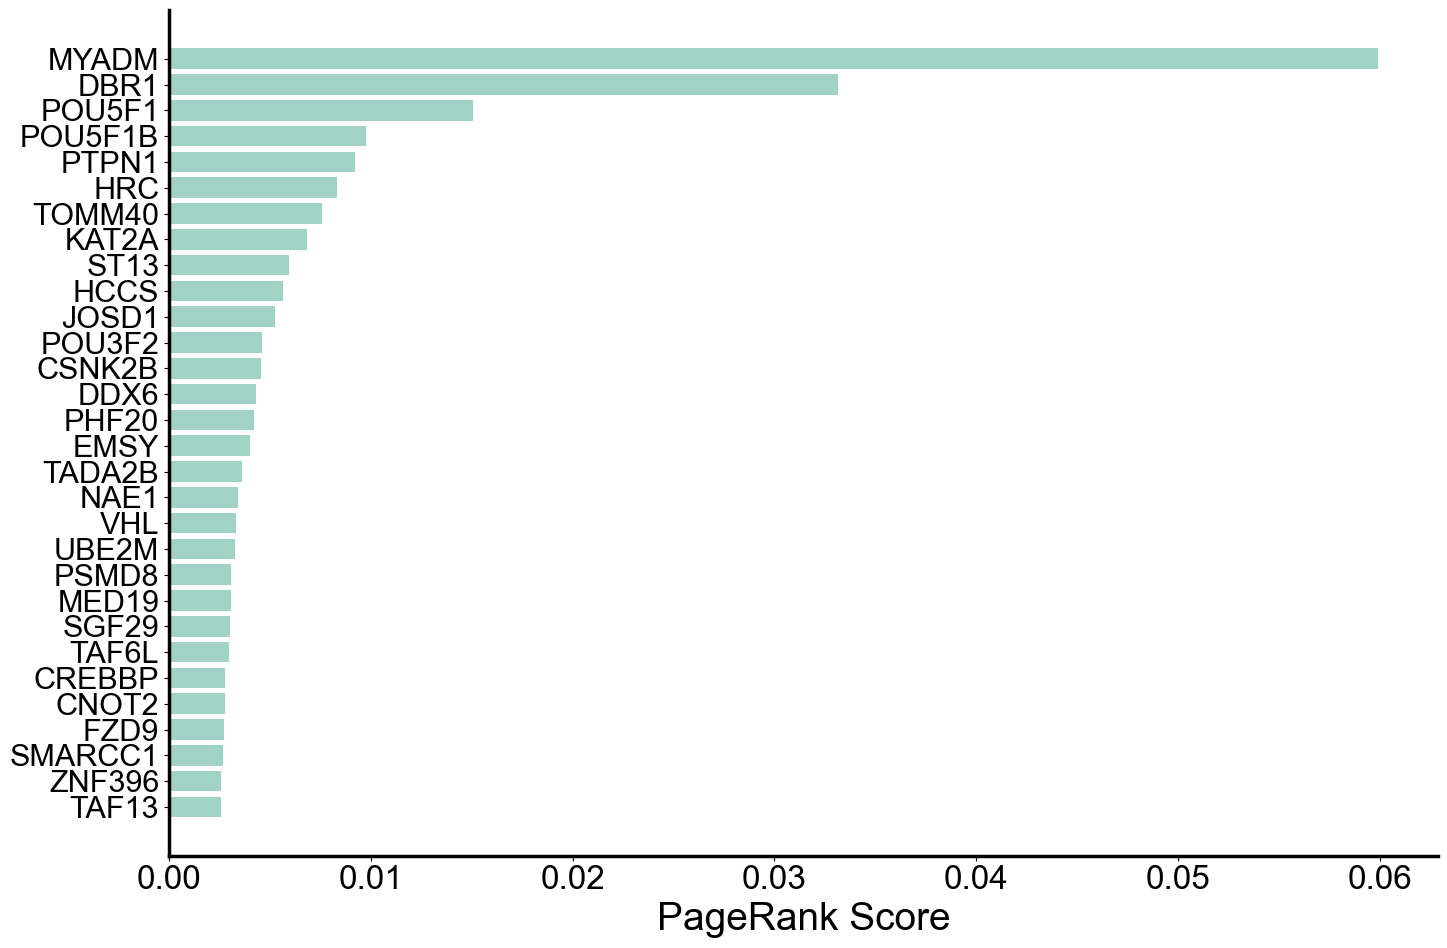


Top 30 Regulatory Genes by PageRank Score:
 1. MYADM: 0.059895
 2. DBR1: 0.033177
 3. POU5F1: 0.015090
 4. POU5F1B: 0.009768
 5. PTPN1: 0.009222
 6. HRC: 0.008308
 7. TOMM40: 0.007589
 8. KAT2A: 0.006819
 9. ST13: 0.005936
10. HCCS: 0.005640
11. JOSD1: 0.005267
12. POU3F2: 0.004611
13. CSNK2B: 0.004573
14. DDX6: 0.004331
15. PHF20: 0.004234
16. EMSY: 0.004039
17. TADA2B: 0.003627
18. NAE1: 0.003431
19. VHL: 0.003306
20. UBE2M: 0.003282
21. PSMD8: 0.003093
22. MED19: 0.003060
23. SGF29: 0.003004
24. TAF6L: 0.002993
25. CREBBP: 0.002791
26. CNOT2: 0.002780
27. FZD9: 0.002739
28. SMARCC1: 0.002698
29. ZNF396: 0.002592
30. TAF13: 0.002557


In [4]:
gene_to_col = {}
for col in DEGs.columns:
    if col.endswith('_DEGs'):
        gene = col.split('_')[0]
        gene_to_col[gene] = col

DEGs_per_gene = {}
for gene in gene_to_col.keys():
    DEGs_per_gene[gene] = list(DEGs[gene_to_col[gene]].dropna())

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# Set font to Arial and increase font size
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 24

# Create a directed graph
G = nx.DiGraph()

# Add nodes for each gene in pluripotency_associated_genes
for gene in DEGs_per_gene:
    G.add_node(gene)

# Add directed edges from upregulated DEGs (78c0af)
for source_gene, target_genes in DEGs_per_gene.items():
    for target_gene in target_genes:
        # Check if the target gene is also a node in our graph
        # and ensure no self-edges
        if target_gene in G.nodes() and source_gene != target_gene:
            G.add_edge(source_gene, target_gene)

print(f"Created full regulatory network with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

# Reverse all edges for PageRank computation
G_reversed = G.reverse()

# Compute PageRank
pagerank_scores = nx.pagerank(G_reversed, alpha=0.85, max_iter=1000)

# Sort genes by PageRank score
sorted_genes = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)

# Get top 30 regulators
top_30_regulators = sorted_genes[:30]

# Create bar plot of top 30 regulators
plt.figure(figsize=(15, 10))
genes, scores = zip(*top_30_regulators)

# Create horizontal bar plot for better readability
y_pos = range(len(genes))
plt.barh(y_pos, scores, color='#78c0af', alpha=0.7)

# Customize the plot
plt.yticks(y_pos, genes, fontsize=22)
plt.xlabel('PageRank Score', fontsize=28, fontfamily='Arial')
# No title

# Make axes thicker
ax = plt.gca()
ax.invert_yaxis()  # Invert y-axis so highest score is at top

# Only show axis lines for x and y axes, remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

# Set axis line width
ax.spines['left'].set_linewidth(2.5)
ax.spines['bottom'].set_linewidth(2.5)

plt.tight_layout()
plt.savefig('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/output_files/Top_30_Regulators_PageRank.svg')
plt.show()

# Print the results
print("\nTop 30 Regulatory Genes by PageRank Score:")
print("=" * 50)
for i, (gene, score) in enumerate(top_30_regulators, 1):
    print(f"{i:2d}. {gene}: {score:.6f}")


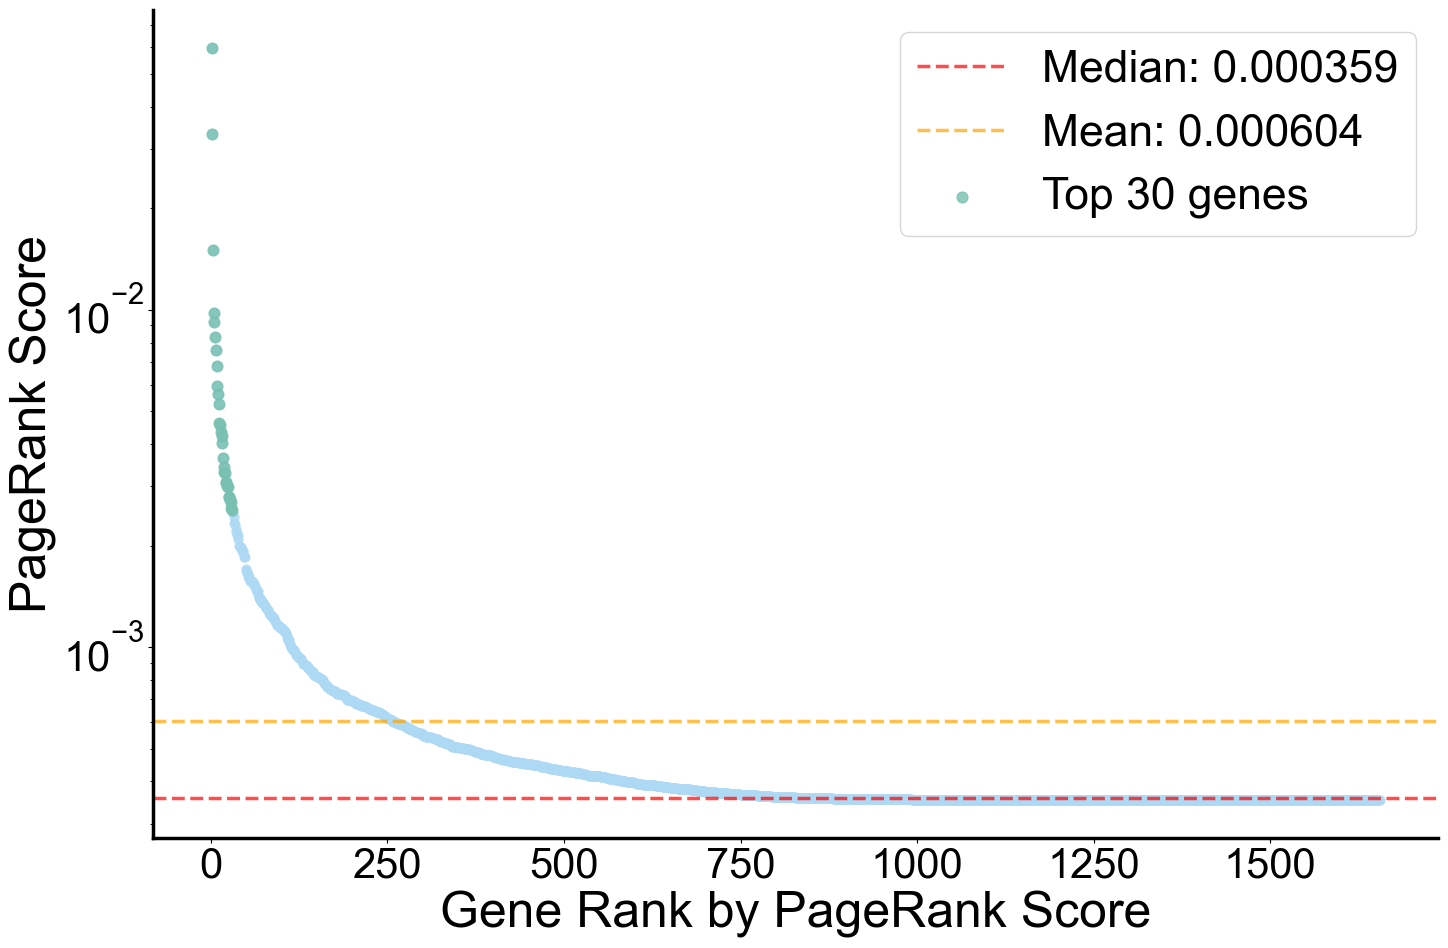


PageRank Score Summary Statistics:
Total genes: 1655
Mean score: 0.000604
Median score: 0.000359
Min score: 0.000352
Max score: 0.059895
Standard deviation: 0.001818
Top 10% threshold: 0.000760
Top 1% threshold: 0.003521


In [11]:
# Create waterfall plot of PageRank scores
plt.figure(figsize=(15, 10))

# Get all PageRank scores and sort them
all_scores = list(pagerank_scores.values())
all_scores.sort(reverse=True)

# Create x-axis (rank positions)
ranks = range(1, len(all_scores) + 1)

# Create waterfall plot as scatter plot
plt.scatter(ranks, all_scores, color='#ADD9F4', alpha=0.8, s=40)

# Add horizontal line at median
median_score = np.median(all_scores)
plt.axhline(y=median_score, color='red', linestyle='--', alpha=0.7, 
            label=f'Median: {median_score:.6f}', linewidth=2.5)

# Add horizontal line at mean
mean_score = np.mean(all_scores)
plt.axhline(y=mean_score, color='orange', linestyle='--', alpha=0.7, 
            label=f'Mean: {mean_score:.6f}', linewidth=2.5)

# Highlight top 30 genes
top_30_scores = all_scores[:30]
plt.scatter(range(1, 31), top_30_scores, color='#78c0af', s=60, alpha=0.8, 
           label='Top 30 genes', zorder=5)

# Customize the plot
plt.xlabel('Gene Rank by PageRank Score', fontsize=36, fontfamily='Arial')
plt.ylabel('PageRank Score', fontsize=36, fontfamily='Arial')
# Add legend
plt.legend(fontsize=32)

# Use log scale for better visualization
plt.yscale('log')
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)

# Make axes thicker
ax = plt.gca()
ax.spines['left'].set_linewidth(2.5)
ax.spines['bottom'].set_linewidth(2.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Remove grid (do not call plt.grid)

plt.tight_layout()
plt.savefig("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/output_files/PageRank_Score_Waterfall_Plot.svg")
plt.show()

# Print summary statistics
print("\nPageRank Score Summary Statistics:")
print("=" * 40)
print(f"Total genes: {len(all_scores)}")
print(f"Mean score: {mean_score:.6f}")
print(f"Median score: {median_score:.6f}")
print(f"Min score: {min(all_scores):.6f}")
print(f"Max score: {max(all_scores):.6f}")
print(f"Standard deviation: {np.std(all_scores):.6f}")
print(f"Top 10% threshold: {np.percentile(all_scores, 90):.6f}")
print(f"Top 1% threshold: {np.percentile(all_scores, 99):.6f}")


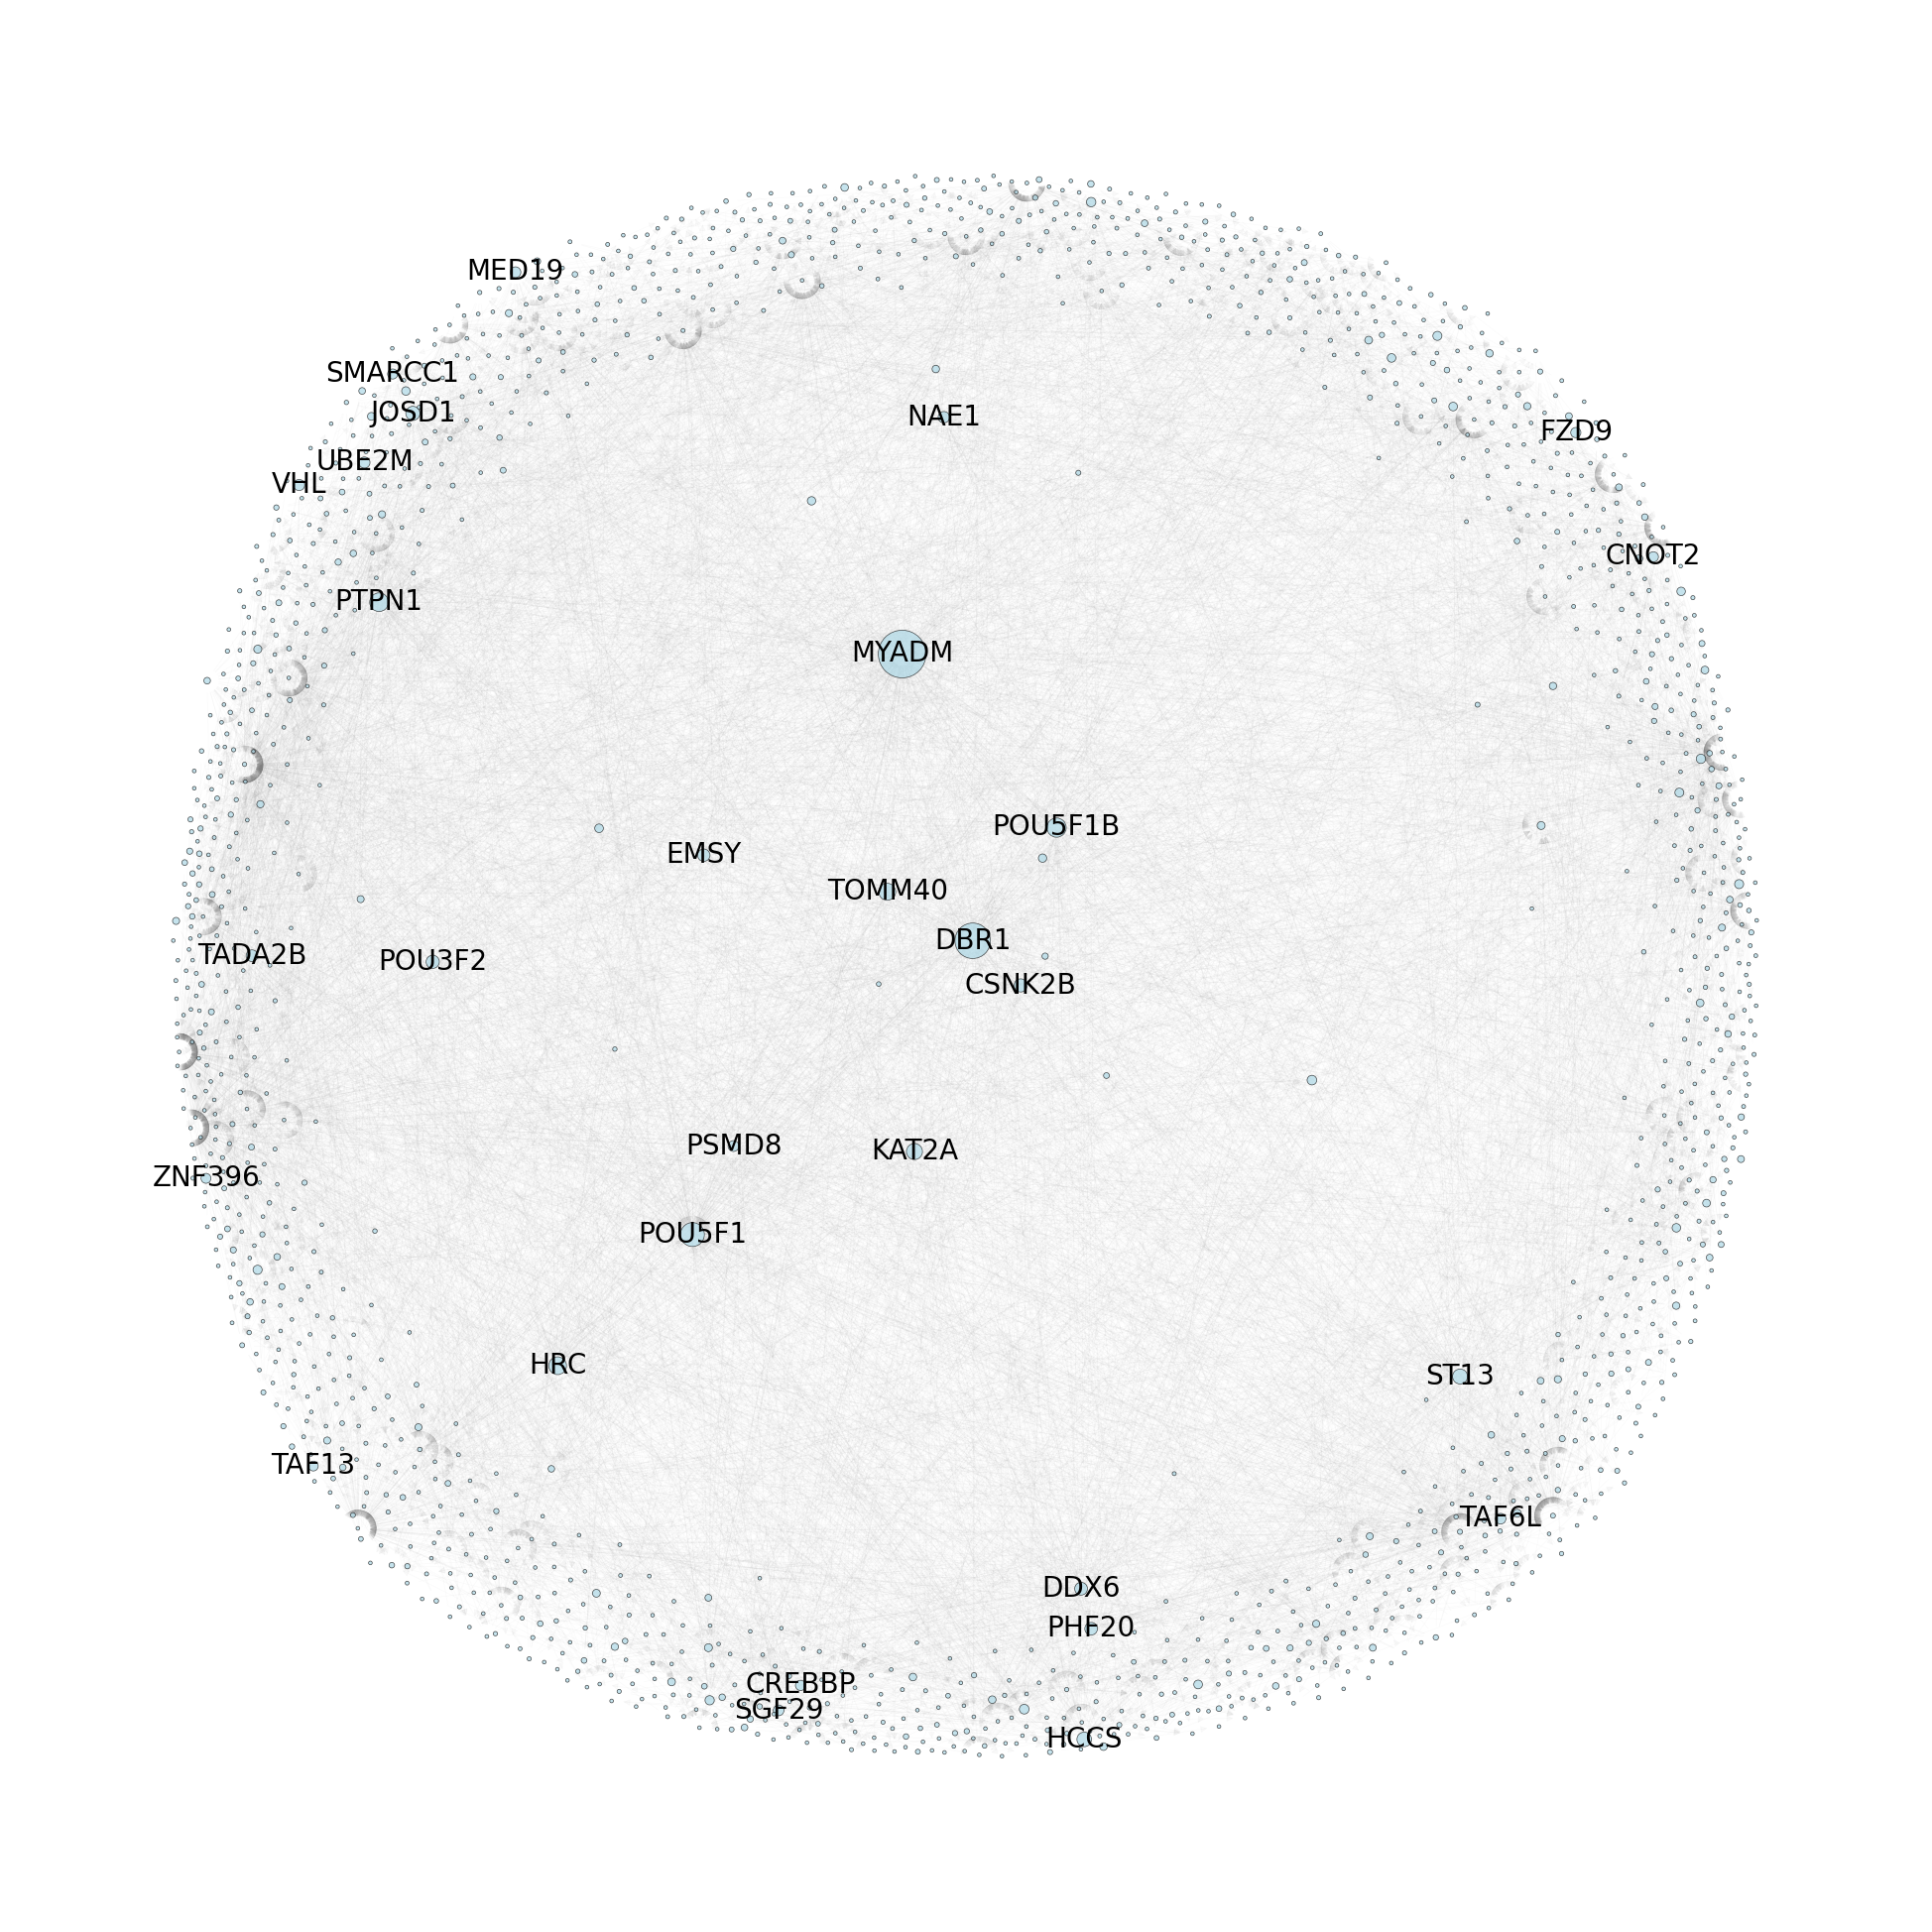


Top 20 Genes by PageRank Score:
 1. MYADM: 0.059895
 2. DBR1: 0.033177
 3. POU5F1: 0.015090
 4. POU5F1B: 0.009768
 5. PTPN1: 0.009222
 6. HRC: 0.008308
 7. TOMM40: 0.007589
 8. KAT2A: 0.006819
 9. ST13: 0.005936
10. HCCS: 0.005640
11. JOSD1: 0.005267
12. POU3F2: 0.004611
13. CSNK2B: 0.004573
14. DDX6: 0.004331
15. PHF20: 0.004234
16. EMSY: 0.004039
17. TADA2B: 0.003627
18. NAE1: 0.003431
19. VHL: 0.003306
20. UBE2M: 0.003282
21. PSMD8: 0.003093
22. MED19: 0.003060
23. SGF29: 0.003004
24. TAF6L: 0.002993
25. CREBBP: 0.002791
26. CNOT2: 0.002780
27. FZD9: 0.002739
28. SMARCC1: 0.002698
29. ZNF396: 0.002592
30. TAF13: 0.002557


In [13]:
# Create the network visualization with PageRank-based node sizes and low alpha edges
plt.figure(figsize=(20, 20))

# Calculate node sizes based on PageRank scores (normalize to reasonable range)
node_sizes = [pagerank_scores.get(node, 0) * 20000 for node in G.nodes()]  # Scale up for visibility

# Draw the network
pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)  # k controls distance between nodes

# Draw edges with very low alpha
nx.draw_networkx_edges(G, pos, alpha=0.04, edge_color='gray', width=0.5)

# Draw nodes with PageRank-based sizes
nx.draw_networkx_nodes(G, pos, 
                      node_size=node_sizes,
                      node_color='lightblue',
                      alpha=0.7,
                      edgecolors='black',
                      linewidths=0.5)

# Add node labels for top PageRank genes
top_nodes = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:30]
top_node_labels = {node: node for node, score in top_nodes}
nx.draw_networkx_labels(G, pos, labels=top_node_labels, font_size=20)

plt.axis('off')
plt.tight_layout()
plt.savefig("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/output_files/full_strong_perturbation_regulatory_network.png", dpi=1200)
plt.show()

# Print top 20 genes by PageRank score
print("\nTop 20 Genes by PageRank Score:")
print("=" * 40)
for i, (gene, score) in enumerate(top_nodes, 1):
    print(f"{i:2d}. {gene}: {score:.6f}")
